# Understanding the Contour Plot

A **contour plot** (also called an isoline or level-set plot) displays a **3D surface** as a 2D map by drawing lines of constant z-value (contours / isolines) across the (x, y) plane. It is the standard way to visualise a **response surface**, joint probability distribution, or any function of two variables without requiring a 3D rendering.

**Reading a contour plot:**
- Each contour line connects all (x, y) points where z = constant
- Closely spaced contours → steep gradient (z changes quickly)
- Widely spaced contours → gentle slope
- Closed contour loops → local maximum or minimum inside the loop
- Nested circles → elliptical bowl (2D Gaussian, quadratic loss surface)

**Common uses in EDA and ML:**
- Joint density of two numerical variables (2D KDE)
- Response surface in a two-factor experiment
- Loss landscape visualisation
- Geographic elevation maps

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

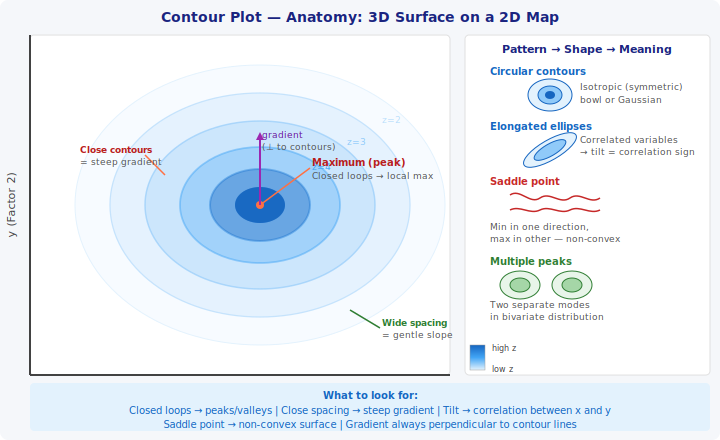

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="440"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="440" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">Contour Plot — Anatomy: 3D Surface on a 2D Map</text>

  <!-- ── MAIN CONTOUR PLOT ── -->
  <rect x="30" y="35" width="420" height="340" fill="white" stroke="#E0E0E0" rx="4"/>

  <!-- Axes -->
  <line x1="30"  y1="375" x2="450" y2="375" stroke="#424242" stroke-width="2"/>
  <line x1="30"  y1="375" x2="30"  y2="35"  stroke="#424242" stroke-width="2"/>
  <text x="240" y="400" text-anchor="middle" font-size="11" fill="#424242">x (Factor 1)</text>
  <text x="15" y="205" text-anchor="middle" font-size="11" fill="#424242"
        transform="rotate(-90 15 205)">y (Factor 2)</text>

  <!-- Contour lines (ellipses centred at approx 260, 205) -->
  <!-- Innermost — highest z value -->
  <ellipse cx="260" cy="205" rx="25" ry="18" fill="#1565C0" fill-opacity="0.85" stroke="none"/>
  <!-- Level 5 -->
  <ellipse cx="260" cy="205" rx="50" ry="36" fill="none" stroke="#1565C0" stroke-width="2"/>
  <!-- Level 4 -->
  <ellipse cx="260" cy="205" rx="80" ry="58" fill="none" stroke="#42A5F5" stroke-width="1.8"/>
  <!-- Level 3 -->
  <ellipse cx="260" cy="205" rx="115" ry="84" fill="none" stroke="#90CAF9" stroke-width="1.5"/>
  <!-- Level 2 -->
  <ellipse cx="260" cy="205" rx="150" ry="112" fill="none" stroke="#BBDEFB" stroke-width="1.3"/>
  <!-- Level 1 (outermost) -->
  <ellipse cx="260" cy="205" rx="185" ry="140" fill="none" stroke="#E3F2FD" stroke-width="1"/>

  <!-- Background fill (gradient effect) -->
  <ellipse cx="260" cy="205" rx="185" ry="140" fill="#E3F2FD" fill-opacity="0.3"/>
  <ellipse cx="260" cy="205" rx="150" ry="112" fill="#BBDEFB" fill-opacity="0.3"/>
  <ellipse cx="260" cy="205" rx="115" ry="84" fill="#90CAF9" fill-opacity="0.3"/>
  <ellipse cx="260" cy="205" rx="80" ry="58" fill="#42A5F5" fill-opacity="0.3"/>
  <ellipse cx="260" cy="205" rx="50" ry="36" fill="#1565C0" fill-opacity="0.4"/>
  <ellipse cx="260" cy="205" rx="25" ry="18" fill="#1565C0" fill-opacity="0.9"/>

  <!-- Z labels on contours -->
  <text x="312" y="170" font-size="9" fill="#42A5F5">z=4</text>
  <text x="347" y="145" font-size="9" fill="#90CAF9">z=3</text>
  <text x="382" y="123" font-size="9" fill="#BBDEFB">z=2</text>

  <!-- Maximum annotation -->
  <circle cx="260" cy="205" r="4" fill="#FF7043"/>
  <line x1="260" y1="205" x2="310" y2="168" stroke="#FF7043" stroke-width="1.5"/>
  <text x="312" y="166" font-size="10" font-weight="bold" fill="#B71C1C">Maximum (peak)</text>
  <text x="312" y="179" font-size="9" fill="#555">Closed loops → local max</text>

  <!-- Steep gradient annotation -->
  <line x1="165" y1="175" x2="145" y2="155" stroke="#FF7043" stroke-width="1.5"/>
  <text x="80" y="153" font-size="9" font-weight="bold" fill="#B71C1C">Close contours</text>
  <text x="80" y="165" font-size="9" fill="#555">= steep gradient</text>

  <!-- Wide contours annotation -->
  <line x1="350" y1="310" x2="380" y2="328" stroke="#2E7D32" stroke-width="1.5"/>
  <text x="382" y="326" font-size="9" font-weight="bold" fill="#2E7D32">Wide spacing</text>
  <text x="382" y="338" font-size="9" fill="#555">= gentle slope</text>

  <!-- Gradient arrow -->
  <line x1="260" y1="205" x2="260" y2="140" stroke="#9C27B0" stroke-width="2"/>
  <polygon points="256,140 264,140 260,132" fill="#9C27B0"/>
  <text x="262" y="138" font-size="9" fill="#6A1B9A">gradient</text>
  <text x="262" y="150" font-size="9" fill="#555">(⊥ to contours)</text>

  <!-- ── RIGHT: interpretation and examples ── -->
  <rect x="465" y="35" width="245" height="340" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="587" y="53" text-anchor="middle" font-size="11" font-weight="bold" fill="#1A237E">Pattern → Shape → Meaning</text>

  <!-- Nested circles: bowl -->
  <text x="490" y="75" font-size="10" font-weight="bold" fill="#1565C0">Circular contours</text>
  <ellipse cx="550" cy="95" rx="22" ry="16" fill="#E3F2FD" stroke="#1565C0" stroke-width="1"/>
  <ellipse cx="550" cy="95" rx="12" ry="9" fill="#90CAF9" stroke="#1565C0" stroke-width="1"/>
  <ellipse cx="550" cy="95" rx="5" ry="4" fill="#1565C0"/>
  <text x="580" y="90" font-size="9" fill="#555">Isotropic (symmetric)</text>
  <text x="580" y="103" font-size="9" fill="#555">bowl or Gaussian</text>

  <!-- Elongated ellipses: correlated -->
  <text x="490" y="130" font-size="10" font-weight="bold" fill="#1565C0">Elongated ellipses</text>
  <ellipse cx="550" cy="150" rx="30" ry="10" fill="#E3F2FD" stroke="#1565C0" stroke-width="1" transform="rotate(-30 550 150)"/>
  <ellipse cx="550" cy="150" rx="18" ry="6" fill="#90CAF9" stroke="#1565C0" stroke-width="1" transform="rotate(-30 550 150)"/>
  <text x="580" y="143" font-size="9" fill="#555">Correlated variables</text>
  <text x="580" y="155" font-size="9" fill="#555">→ tilt = correlation sign</text>

  <!-- Saddle point -->
  <text x="490" y="185" font-size="10" font-weight="bold" fill="#C62828">Saddle point</text>
  <path d="M 510,195 C 520,188 530,205 540,198 C 550,191 560,205 570,198 C 580,191 590,205 600,198"
        fill="none" stroke="#C62828" stroke-width="1.5"/>
  <path d="M 510,210 C 520,205 530,215 540,210 C 550,205 560,215 570,210 C 580,205 590,215 600,210"
        fill="none" stroke="#C62828" stroke-width="1.5"/>
  <text x="490" y="230" font-size="9" fill="#555">Min in one direction,</text>
  <text x="490" y="242" font-size="9" fill="#555">max in other — non-convex</text>

  <!-- Multiple peaks -->
  <text x="490" y="265" font-size="10" font-weight="bold" fill="#2E7D32">Multiple peaks</text>
  <ellipse cx="520" cy="285" rx="20" ry="14" fill="#E8F5E9" stroke="#2E7D32" stroke-width="1"/>
  <ellipse cx="520" cy="285" rx="10" ry="7" fill="#A5D6A7" stroke="#2E7D32" stroke-width="1"/>
  <ellipse cx="572" cy="285" rx="20" ry="14" fill="#E8F5E9" stroke="#2E7D32" stroke-width="1"/>
  <ellipse cx="572" cy="285" rx="10" ry="7" fill="#A5D6A7" stroke="#2E7D32" stroke-width="1"/>
  <text x="490" y="308" font-size="9" fill="#555">Two separate modes</text>
  <text x="490" y="320" font-size="9" fill="#555">in bivariate distribution</text>

  <!-- Colour bar -->
  <defs>
    <linearGradient id="cbar" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0%" stop-color="#1565C0"/>
      <stop offset="50%" stop-color="#42A5F5"/>
      <stop offset="100%" stop-color="#E3F2FD"/>
    </linearGradient>
  </defs>
  <rect x="470" y="345" width="15" height="25" fill="url(#cbar)" stroke="#9E9E9E" stroke-width="0.5"/>
  <text x="492" y="351" font-size="8" fill="#424242">high z</text>
  <text x="492" y="372" font-size="8" fill="#424242">low z</text>

  <!-- Takeaway -->
  <rect x="30" y="383" width="680" height="48" fill="#E3F2FD" rx="4"/>
  <text x="370" y="399" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">What to look for:</text>
  <text x="370" y="414" text-anchor="middle" font-size="10" fill="#1565C0">Closed loops → peaks/valleys   |   Close spacing → steep gradient   |   Tilt → correlation between x and y</text>
  <text x="370" y="428" text-anchor="middle" font-size="10" fill="#1565C0">Saddle point → non-convex surface   |   Gradient always perpendicular to contour lines</text>
</svg>
"""
display(SVG(_svg))

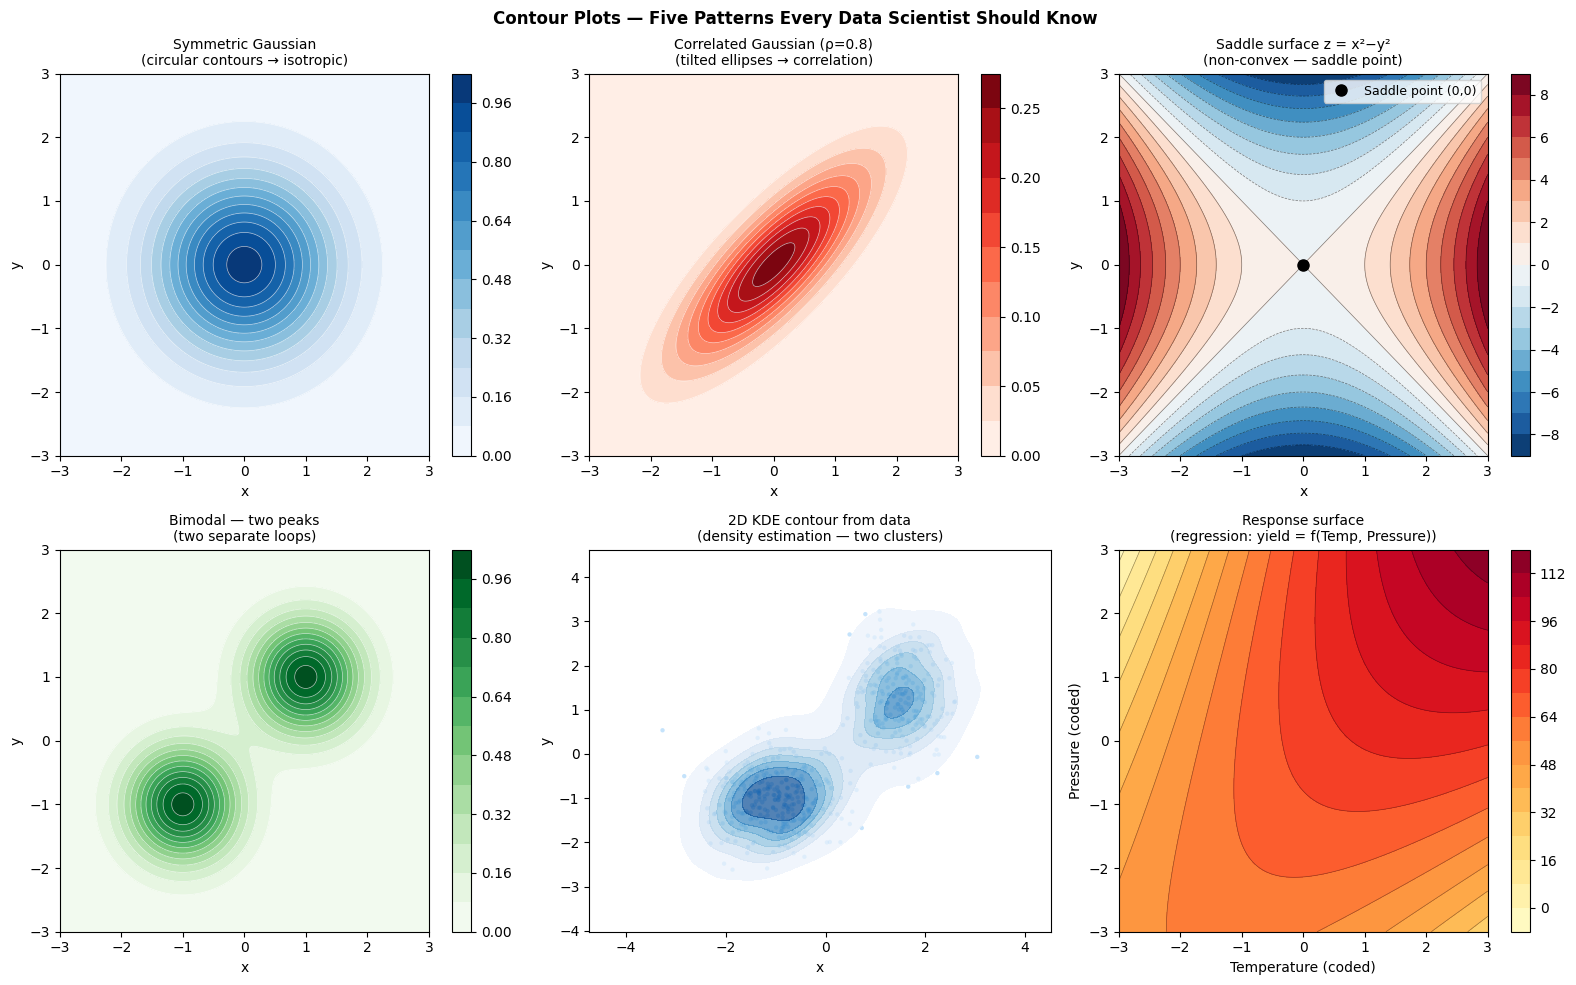

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Contour Plots — Five Patterns Every Data Scientist Should Know', fontsize=12, fontweight='bold')

x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)

# 1: Simple Gaussian (circular)
Z1 = np.exp(-(X**2 + Y**2) / 2)
cs = axes[0, 0].contourf(X, Y, Z1, levels=12, cmap='Blues')
axes[0, 0].contour(X, Y, Z1, levels=12, colors='white', linewidths=0.5, alpha=0.7)
fig.colorbar(cs, ax=axes[0, 0])
axes[0, 0].set_title('Symmetric Gaussian\n(circular contours → isotropic)', fontsize=10)
axes[0, 0].set_xlabel('x'); axes[0, 0].set_ylabel('y')

# 2: Correlated Gaussian (tilted ellipse)
cov = np.array([[1.0, 0.8], [0.8, 1.0]])
mv = stats.multivariate_normal(mean=[0, 0], cov=cov)
pos = np.dstack([X, Y])
Z2 = mv.pdf(pos)
cs = axes[0, 1].contourf(X, Y, Z2, levels=12, cmap='Reds')
axes[0, 1].contour(X, Y, Z2, levels=12, colors='white', linewidths=0.5, alpha=0.7)
fig.colorbar(cs, ax=axes[0, 1])
axes[0, 1].set_title('Correlated Gaussian (ρ=0.8)\n(tilted ellipses → correlation)', fontsize=10)
axes[0, 1].set_xlabel('x'); axes[0, 1].set_ylabel('y')

# 3: Saddle surface
Z3 = X**2 - Y**2
cs = axes[0, 2].contourf(X, Y, Z3, levels=20, cmap='RdBu_r')
axes[0, 2].contour(X, Y, Z3, levels=20, colors='black', linewidths=0.5, alpha=0.5)
axes[0, 2].plot(0, 0, 'ko', markersize=8, label='Saddle point (0,0)')
fig.colorbar(cs, ax=axes[0, 2])
axes[0, 2].set_title('Saddle surface z = x²−y²\n(non-convex — saddle point)', fontsize=10)
axes[0, 2].set_xlabel('x'); axes[0, 2].set_ylabel('y')
axes[0, 2].legend(fontsize=9)

# 4: Bimodal (two peaks)
Z4 = (np.exp(-((X-1)**2 + (Y-1)**2)/0.8) +
      np.exp(-((X+1)**2 + (Y+1)**2)/0.8))
cs = axes[1, 0].contourf(X, Y, Z4, levels=12, cmap='Greens')
axes[1, 0].contour(X, Y, Z4, levels=12, colors='white', linewidths=0.5, alpha=0.7)
fig.colorbar(cs, ax=axes[1, 0])
axes[1, 0].set_title('Bimodal — two peaks\n(two separate loops)', fontsize=10)
axes[1, 0].set_xlabel('x'); axes[1, 0].set_ylabel('y')

# 5: 2D KDE from data
np.random.seed(42)
data_x = np.concatenate([np.random.normal(-1, 0.7, 300), np.random.normal(1.5, 0.5, 200)])
data_y = np.concatenate([np.random.normal(-1, 0.6, 300), np.random.normal(1.2, 0.8, 200)])
axes[1, 1].scatter(data_x, data_y, alpha=0.3, s=10, color='#42A5F5', edgecolors='none', label='Data')
sns.kdeplot(x=data_x, y=data_y, ax=axes[1, 1], fill=True, levels=8, cmap='Blues', alpha=0.7)
axes[1, 1].set_title('2D KDE contour from data\n(density estimation — two clusters)', fontsize=10)
axes[1, 1].set_xlabel('x'); axes[1, 1].set_ylabel('y')

# 6: Response surface (from regression model)
Z6 = 75 + 8*X + 3*Y + 4*X*Y - 2*X**2 - Y**2
cs = axes[1, 2].contourf(X, Y, Z6, levels=15, cmap='YlOrRd')
axes[1, 2].contour(X, Y, Z6, levels=15, colors='black', linewidths=0.5, alpha=0.4)
fig.colorbar(cs, ax=axes[1, 2])
axes[1, 2].set_title('Response surface\n(regression: yield = f(Temp, Pressure))', fontsize=10)
axes[1, 2].set_xlabel('Temperature (coded)'); axes[1, 2].set_ylabel('Pressure (coded)')

plt.tight_layout()
plt.show()

## Key Takeaways

| | |
|---|---|
| **Purpose** | Visualise any function or density of two variables on a 2D map |
| **Contour line** | Connects all points where z = constant |
| **Closely spaced** | Steep gradient — z changes quickly |
| **Widely spaced** | Gentle slope — z changes slowly |
| **Closed loop** | Local maximum (peak) or minimum (valley) inside |
| **Tilted ellipses** | Variables are correlated — tilt direction = sign of correlation |
| **Saddle point** | Non-convex — minimum in one direction, maximum in another |
| **`contourf`** | Filled contour (matplotlib) |
| **`contour`** | Line-only contour |
| **`sns.kdeplot(..., fill=True)`** | Filled 2D KDE contour in seaborn |
| **Colour bar** | Always include to decode z values |